In [1]:
# 7-5 DBSCAN

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

iris = load_iris()
feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

df = pd.DataFrame(data = iris.data, columns = feature_names)
df["target"] = iris.target

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.6, min_samples = 8, metric = "euclidean")
dbscan_label = dbscan.fit_predict(iris.data)

df["dbscan_cluster"] = dbscan_label
df["target"] = iris.target

res = df.groupby(["target"])["dbscan_cluster"].value_counts()
print(res)

target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: count, dtype: int64


In [4]:
# 클러스터 시각화 함수

def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):
    if iscenter :
        centers = clusterobj.cluster_centers_
        
    unique_labels = np.unique(dataframe[label_name].values)
    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name]==label]
        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else :
            cluster_legend = 'Cluster '+str(label)
        
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,\
                    edgecolor='k', marker=markers[label], label=cluster_legend)
        
        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',
                        edgecolor='k', marker='$%d$' % label)
    if isNoise:
        legend_loc='upper center'
    else: legend_loc='upper right'
    
    plt.legend(loc=legend_loc)
    plt.show()

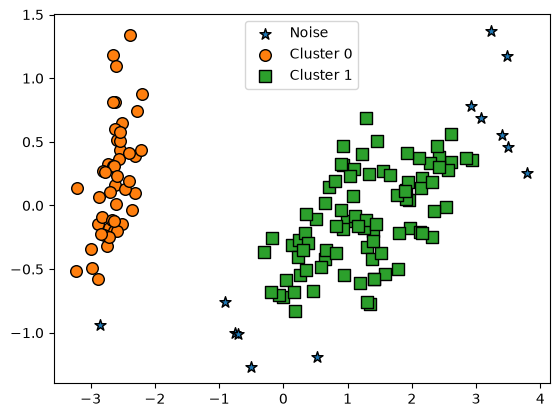

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2, random_state = 42)
pca_trans = pca.fit_transform(iris.data)

df["ftr1"] = pca_trans[:, 0]
df["ftr2"] = pca_trans[:, 1]

visualize_cluster_plot(dbscan, df, "dbscan_cluster", iscenter = False)

target  dbscan_cluster
0        0                50
1        1                50
2        1                47
        -1                 3
Name: count, dtype: int64


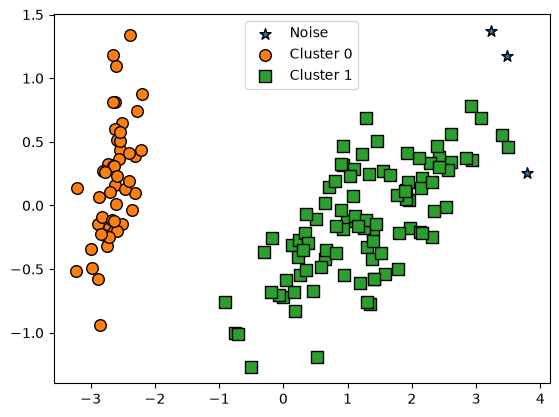

In [ ]:
# 입실론 조정
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.8, min_samples = 8, metric = "euclidean")
dbscan_label = dbscan.fit_predict(iris.data)

df["dbscan_cluster"] = dbscan_label
df["target"] = iris.target

res = df.groupby(["target"])["dbscan_cluster"].value_counts()
print(res)

visualize_cluster_plot(dbscan, df, "dbscan_cluster", iscenter = False)

target  dbscan_cluster
0        0                48
        -1                 2
1        1                44
        -1                 6
2        1                36
        -1                14
Name: count, dtype: int64


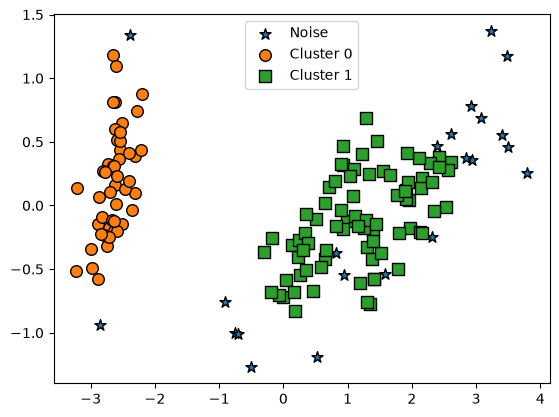

In [9]:
# min_sample 조정
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.6, min_samples = 16, metric = "euclidean")
dbscan_label = dbscan.fit_predict(iris.data)

df["dbscan_cluster"] = dbscan_label
df["target"] = iris.target

res = df.groupby(["target"])["dbscan_cluster"].value_counts()
print(res)

visualize_cluster_plot(dbscan, df, "dbscan_cluster", iscenter = False)

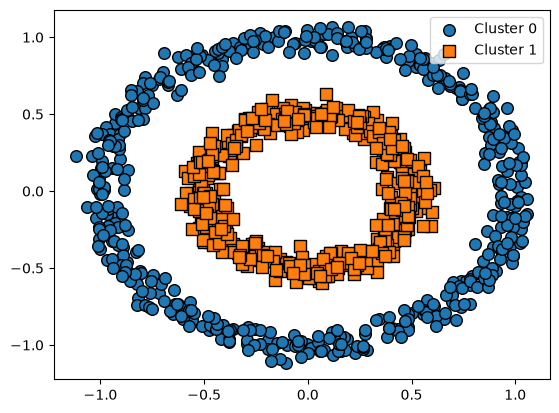

In [12]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples = 1000, shuffle = True, noise = 0.05, random_state = 42, factor = 0.5)

df = pd.DataFrame(data = X, columns = ["ftr1", "ftr2"])
df["target"] = y

visualize_cluster_plot(None, df, "target", iscenter = False)

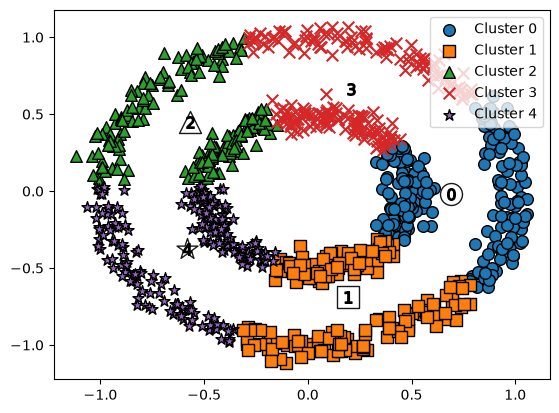

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 5, max_iter = 1000, random_state = 42)
kmeans_label = kmeans.fit_predict(X)
df["kmeans_cluster"] = kmeans_label

visualize_cluster_plot(kmeans, df, "kmeans_cluster", iscenter = True)

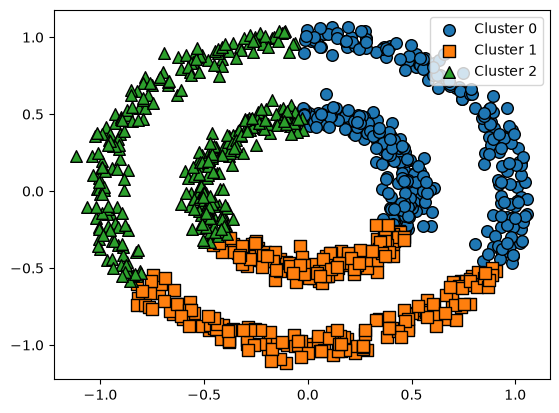

In [22]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components = 3, random_state = 42)
gmm_label = gmm.fit_predict(X)
df["gmm_cluster"] = gmm_label

visualize_cluster_plot(gmm, df, "gmm_cluster", iscenter = False)

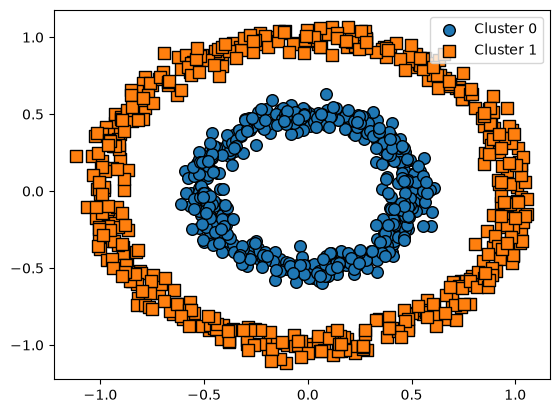

In [19]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.2, min_samples = 10, metric = "euclidean")
dbscan_label = dbscan.fit_predict(X)
df["dbscan_cluster"] = dbscan_label

visualize_cluster_plot(dbscan, df, "dbscan_cluster", iscenter = False)